In [21]:
import yfinance as yf
import numpy as np
import pandas as pd

ticker = 'SPY'
start_date = '2010-01-01'
end_date = '2023-12-31'

print("Downloading data...")
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False)

adj_close = df['Adj Close'].dropna()

log_returns = np.log(adj_close / adj_close.shift(1)).dropna()
print(f"Total log-returns calculated: {len(log_returns)}")

SEQ_LENGTH = 64
sequences = []

for i in range(len(log_returns) - SEQ_LENGTH + 1):
    seq = log_returns.iloc[i : i + SEQ_LENGTH].values
    sequences.append(seq)

X = np.array(sequences)
X = np.squeeze(X) 
print(f"Total overlapping sequences created: {X.shape[0]}")

split_index = int(len(X) * 0.90)

X_train = X[:split_index]
X_test = X[split_index:]
print(f"Train set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


train_mean = X_train.mean()
train_std = X_train.std()

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

print(f"Global Train Mean: {train_mean:.6f}, Global Train Std: {train_std:.6f}")
print("Data preparation completed successfully.")

[*********************100%***********************]  1 of 1 completed

Total log-returns calculated: 3521
Total overlapping sequences created: 3458
Train set shape: (3112, 64)
Test set shape: (346, 64)
Global Train Mean: 0.000480, Global Train Std: 0.010951
Data preparation completed successfully.


In [22]:
import torch
from torch.utils.data import Dataset, DataLoader

class SPYTimeSeriesDataset(Dataset):
    def __init__(self, data_array):
        self.data = torch.tensor(data_array, dtype=torch.float32)
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):

        return self.data[idx]

train_dataset = SPYTimeSeriesDataset(X_train_scaled)
test_dataset = SPYTimeSeriesDataset(X_test_scaled)

BATCH_SIZE = 128

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

for batch in train_loader:
    print(f"Batch shape: {batch.shape}") 
    break

Batch shape: torch.Size([128, 64])


In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
from torchinfo import summary

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = t * embeddings.unsqueeze(0) 
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResBlock(nn.Module):
    def __init__(self, dim, dropout_rate=0.2):
        super().__init__()
        self.linear1 = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout_rate) 
        self.linear2 = nn.Linear(dim, dim)
        self.act = nn.SiLU()

    def forward(self, x):
        h = self.act(self.linear1(x))
        h = self.dropout(h) 
        h = self.linear2(h)
        return x + h
class FlowMatchingModel(nn.Module):
    def __init__(self, input_dim=64, hidden_dim=256, time_emb_dim=128):
        super().__init__()
        
        self.time_embed = SinusoidalTimeEmbedding(time_emb_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        
        self.res_blocks = nn.ModuleList([
            ResBlock(hidden_dim),
            ResBlock(hidden_dim),
            ResBlock(hidden_dim)
        ])
        
        self.act = nn.SiLU()
        self.output_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, t):
        t_emb = self.time_mlp(self.time_embed(t))
        
        h = self.input_proj(x)
        
        h = h + t_emb
        for block in self.res_blocks:
            h = block(self.act(h))
            
        out = self.output_proj(self.act(h))
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FlowMatchingModel().to(device)

BATCH_SIZE = 512
LEARNING_RATE = 8e-4
EPOCHS = 100

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
criterion = nn.MSELoss()

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8,
)

print("\n--- Model Summary ---")
summary(model, input_size=[(BATCH_SIZE, 64), (BATCH_SIZE, 1)], col_names=["input_size", "output_size", "num_params"])


--- Model Summary ---


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
FlowMatchingModel                        [512, 64]                 [512, 64]                 --
├─SinusoidalTimeEmbedding: 1-1           [512, 1]                  [512, 128]                --
├─Sequential: 1-2                        [512, 128]                [512, 256]                --
│    └─Linear: 2-1                       [512, 128]                [512, 256]                33,024
│    └─SiLU: 2-2                         [512, 256]                [512, 256]                --
│    └─Linear: 2-3                       [512, 256]                [512, 256]                65,792
├─Linear: 1-3                            [512, 64]                 [512, 256]                16,640
├─SiLU: 1-4                              [512, 256]                [512, 256]                --
├─ModuleList: 1-9                        --                        --                        (recursive)
│    └─ResBloc

In [24]:
import torch
import numpy as np

class EarlyStopping:

    def __init__(self, patience=20, min_delta=0.0001, path='best_flow_model.pth'):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss, model):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(val_loss, model)
        else:
            self.counter += 1
            print(f" -> EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
                print(" -> Early Stopping Triggered! Halting training.")

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)

In [25]:
from tqdm import tqdm

train_losses = []
test_losses = []

early_stopper = EarlyStopping(patience=20, min_delta=1e-4)

print(f"\nStarting Training on {device} for {EPOCHS} epochs...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_train_loss = 0.0
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch:03d}/{EPOCHS} [Train]", leave=False)
    
    for x1 in train_pbar:
        x1 = x1.to(device)
        B = x1.shape[0]
        
        x0 = torch.randn_like(x1).to(device)
        t = torch.rand(B, 1).to(device)
        
        xt = t * x1 + (1 - t) * x0
        target_vector_field = x1 - x0
        
        optimizer.zero_grad()
        predicted_vector_field = model(xt, t)
        
        loss = criterion(predicted_vector_field, target_vector_field)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_train_loss += loss.item() * B
        train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    model.eval()
    running_test_loss = 0.0
    
    with torch.no_grad():
        for x1 in test_loader:
            x1 = x1.to(device)
            B = x1.shape[0]
            
            x0 = torch.randn_like(x1).to(device)
            t = torch.rand(B, 1).to(device)
            
            xt = t * x1 + (1 - t) * x0
            target_vector_field = x1 - x0
            
            predicted_vector_field = model(xt, t)
            loss = criterion(predicted_vector_field, target_vector_field)
            
            running_test_loss += loss.item() * B

    epoch_test_loss = running_test_loss / len(test_dataset)
    test_losses.append(epoch_test_loss)
    
    scheduler.step(epoch_test_loss)
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:03d}/{EPOCHS} | Train Loss: {epoch_train_loss:.5f} | Test Loss: {epoch_test_loss:.5f} | LR: {current_lr:.6f}")
    early_stopper(epoch_test_loss, model)
    
    if early_stopper.early_stop:
        break

print("\n Training Session Ended.")

model.load_state_dict(torch.load('best_flow_model.pth'))
print("Loaded the best model weights from the checkpoint.")


Starting Training on cuda for 100 epochs...


Epoch 001/100 | Train Loss: 2.00362 | Test Loss: 2.06029 | LR: 0.000800


Epoch 002/100 | Train Loss: 1.98278 | Test Loss: 2.06436 | LR: 0.000800
 -> EarlyStopping counter: 1 out of 20


Epoch 003/100 | Train Loss: 1.96550 | Test Loss: 2.05544 | LR: 0.000800


Epoch 004/100 | Train Loss: 1.95499 | Test Loss: 2.04824 | LR: 0.000800


...

Epoch 092/100 | Train Loss: 1.54624 | Test Loss: 1.71731 | LR: 0.000050
 -> EarlyStopping counter: 16 out of 20


Epoch 093/100 | Train Loss: 1.52583 | Test Loss: 1.71632 | LR: 0.000050
 -> EarlyStopping counter: 17 out of 20


Epoch 094/100 | Train Loss: 1.52518 | Test Loss: 1.72668 | LR: 0.000025
 -> EarlyStopping counter: 18 out of 20


Epoch 095/100 | Train Loss: 1.52245 | Test Loss: 1.77601 | LR: 0.000025
 -> EarlyStopping counter: 19 out of 20


Epoch 096/100 | Train Loss: 1.54526 | Test Loss: 1.74402 | LR: 0.000025
 -> EarlyStopping counter: 20 out of 20
 -> Early Stopping Triggered! Halting training.

 Training Session Ended.
Loaded the best model weights from the checkpoint.


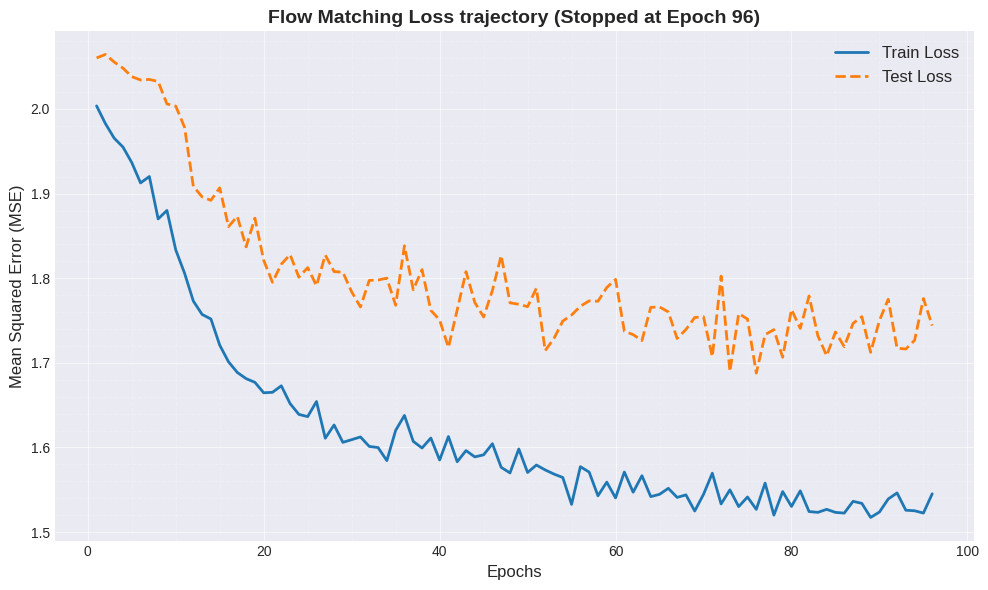

In [26]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(10, 6))

actual_epochs = len(train_losses)
x_axis = range(1, actual_epochs + 1)

plt.plot(x_axis, train_losses, label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(x_axis, test_losses, label='Test Loss', color='#ff7f0e', linewidth=2, linestyle='--')

plt.title(f'Flow Matching Loss trajectory (Stopped at Epoch {actual_epochs})', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, which='major', linestyle='-', alpha=0.6)
plt.grid(True, which='minor', linestyle='--', alpha=0.2)
plt.minorticks_on()

plt.tight_layout()
plt.show()

Starting generation process...
Successfully generated 5 synthetic sequences with shape (5, 64)


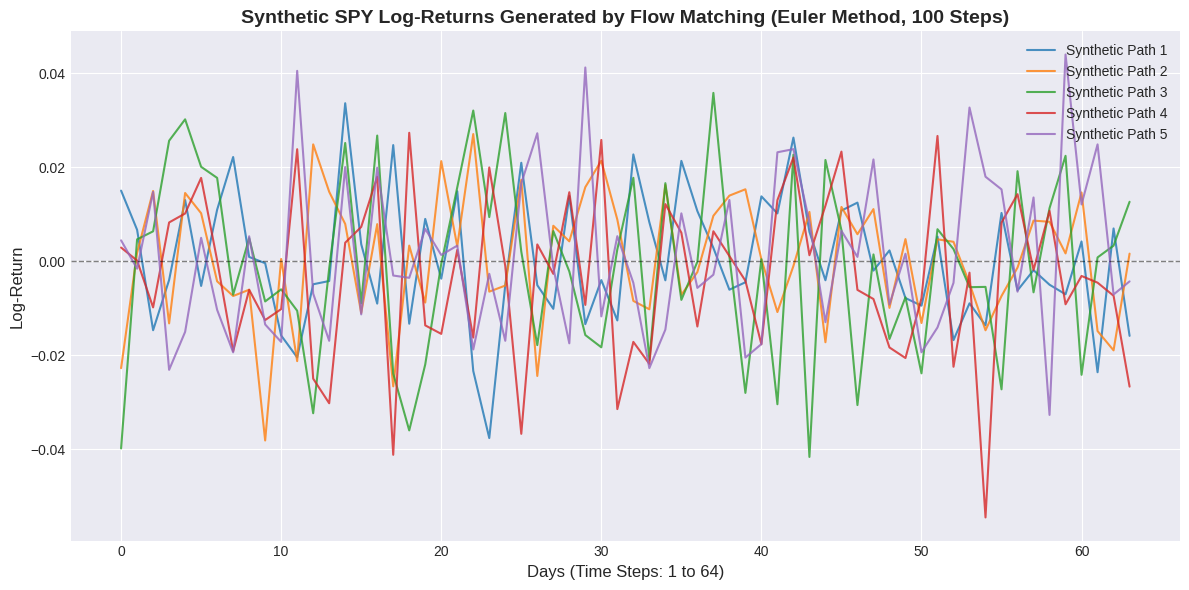

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def generate_synthetic_returns(model, num_samples, num_steps=50, device='cpu'):

    model.eval()


    x = torch.randn(num_samples, 64).to(device)
    
    dt = 1.0 / num_steps
    
    with torch.no_grad():
        for step in range(num_steps):
            t_val = step * dt
            
            t_tensor = torch.full((num_samples, 1), t_val).to(device)
            
            v = model(x, t_tensor)
            
            x = x + v * dt
            
    return x.cpu().numpy()


print("Starting generation process...")
NUM_SAMPLES_TO_GENERATE = 5
STEPS = 100 

synthetic_scaled_data = generate_synthetic_returns(
    model=model, 
    num_samples=NUM_SAMPLES_TO_GENERATE, 
    num_steps=STEPS, 
    device=device
)


synthetic_real_returns = (synthetic_scaled_data * train_std) + train_mean

print(f"Successfully generated {NUM_SAMPLES_TO_GENERATE} synthetic sequences with shape {synthetic_real_returns.shape}")


plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 6))

for i in range(NUM_SAMPLES_TO_GENERATE):
    plt.plot(synthetic_real_returns[i], label=f'Synthetic Path {i+1}', alpha=0.8, linewidth=1.5)

plt.title(f'Synthetic SPY Log-Returns Generated by Flow Matching (Euler Method, {STEPS} Steps)', fontsize=14, fontweight='bold')
plt.xlabel('Days (Time Steps: 1 to 64)', fontsize=12)
plt.ylabel('Log-Return', fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5) 
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

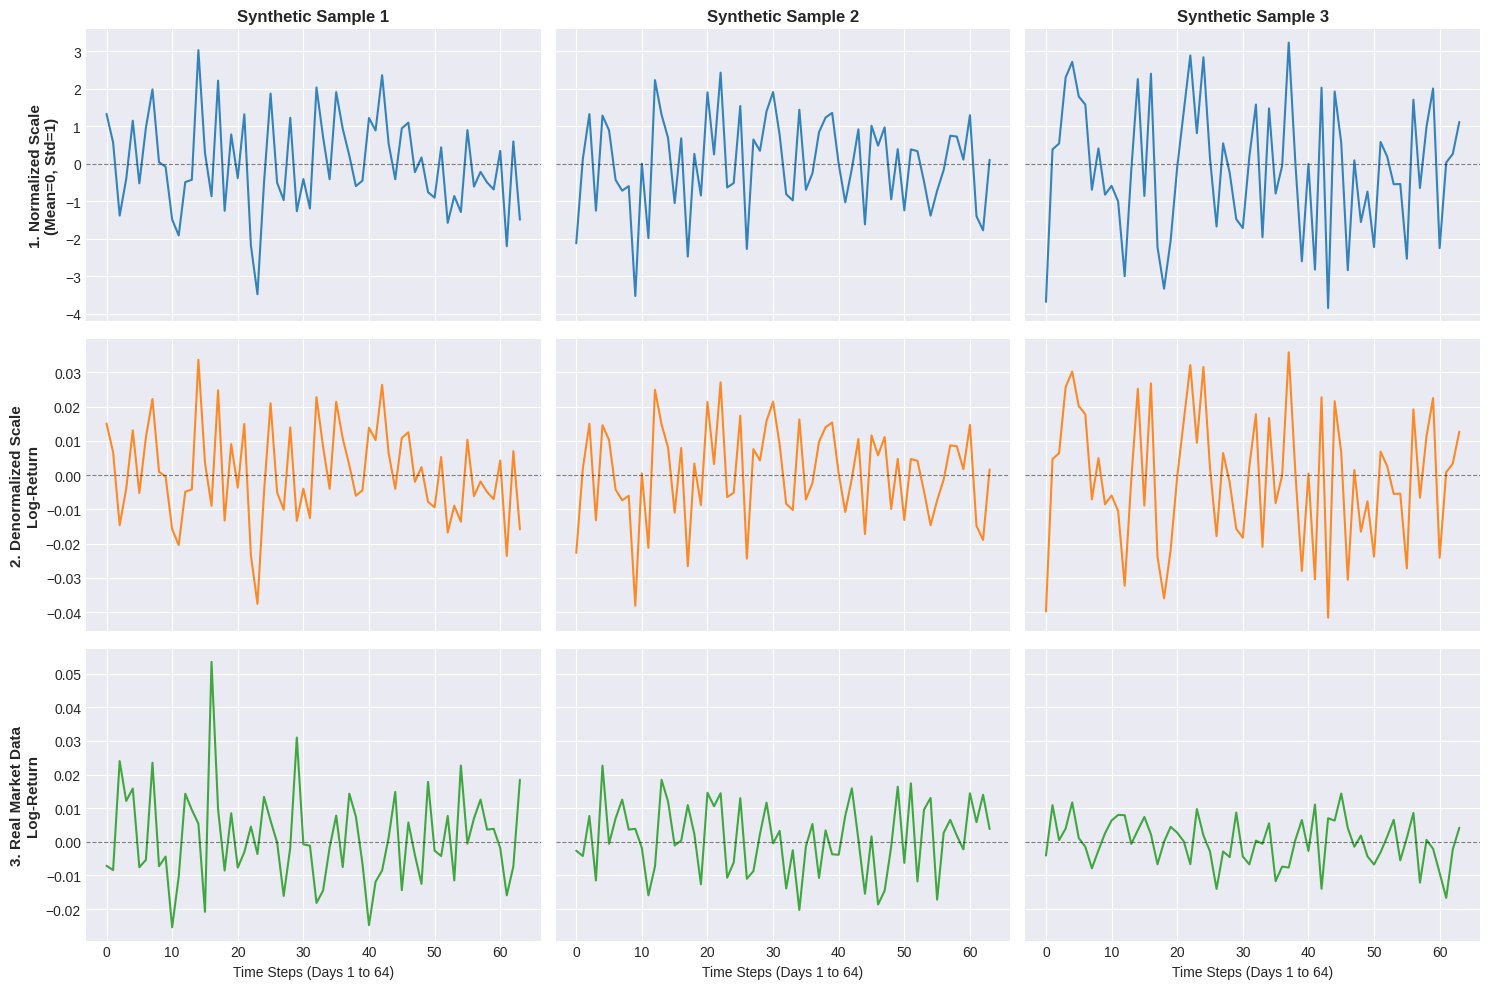

In [29]:
import matplotlib.pyplot as plt
import numpy as np

NUM_PLOT = 3


fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex='col', sharey='row')
plt.style.use('seaborn-v0_8-darkgrid')


for i in range(NUM_PLOT):
    ax = axes[0, i] 
    ax.plot(synthetic_scaled_data[i], color='#1f77b4', linewidth=1.5, alpha=0.9)
    ax.set_title(f'Synthetic Sample {i+1}', fontsize=12, fontweight='bold')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    

    if i == 0:
        ax.set_ylabel('1. Normalized Scale\n(Mean=0, Std=1)', fontsize=11, fontweight='bold')

for i in range(NUM_PLOT):
    ax = axes[1, i] 
    ax.plot(synthetic_real_returns[i], color='#ff7f0e', linewidth=1.5, alpha=0.9)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
    if i == 0:
        ax.set_ylabel('2. Denormalized Scale\nLog-Return', fontsize=11, fontweight='bold')


np.random.seed(42) 
random_indices = np.random.choice(len(X_test), NUM_PLOT, replace=False)

for i, idx in enumerate(random_indices):
    ax = axes[2, i] 
    ax.plot(X_test[idx], color='#2ca02c', linewidth=1.5, alpha=0.9)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Time Steps (Days 1 to 64)', fontsize=10)
    
    if i == 0:
        ax.set_ylabel('3. Real Market Data\nLog-Return', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

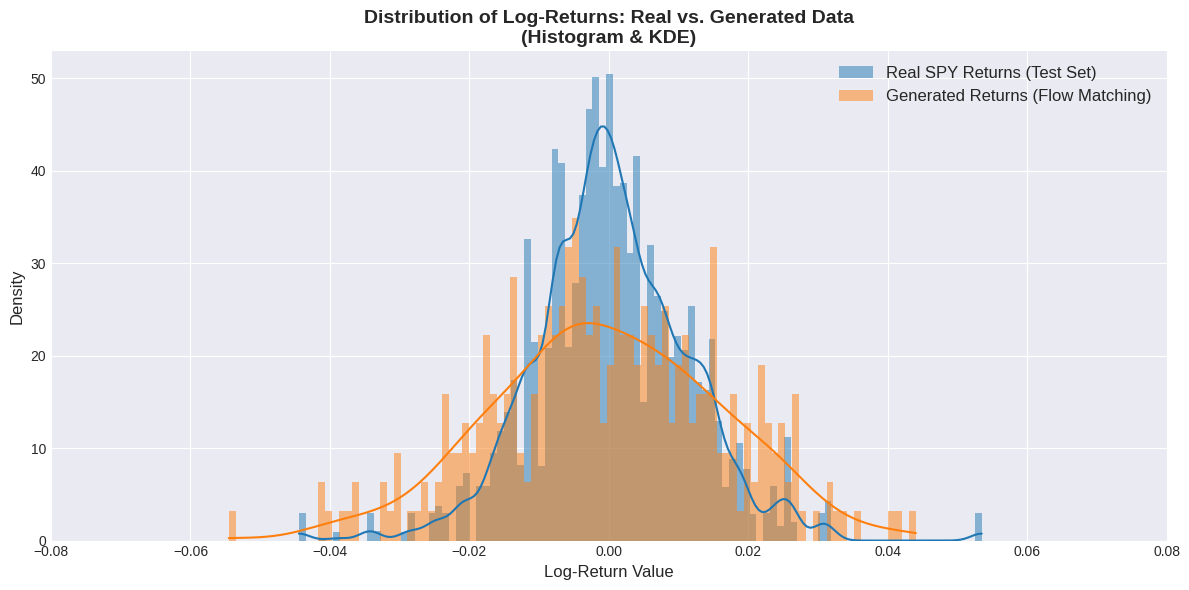

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

real_returns_flat = X_test.flatten()
synthetic_returns_flat = synthetic_real_returns.flatten()

plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-darkgrid')

sns.histplot(real_returns_flat, bins=100, stat="density", kde=True, 
             color="#1f77b4", label="Real SPY Returns (Test Set)", alpha=0.5, linewidth=0)

sns.histplot(synthetic_returns_flat, bins=100, stat="density", kde=True, 
             color="#ff7f0e", label="Generated Returns (Flow Matching)", alpha=0.5, linewidth=0)

plt.title('Distribution of Log-Returns: Real vs. Generated Data\n(Histogram & KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Log-Return Value', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.xlim([-0.08, 0.08]) 

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [31]:
import numpy as np

real_mean = np.mean(real_returns_flat)
real_variance = np.var(real_returns_flat)
real_volatility = np.std(real_returns_flat) 

synthetic_mean = np.mean(synthetic_returns_flat)
synthetic_variance = np.var(synthetic_returns_flat)
synthetic_volatility = np.std(synthetic_returns_flat)

print("-" * 50)
print(f"{'Metric':<15} | {'Real Data (SPY)':<20} | {'Generated Data':<20}")
print("-" * 50)
print(f"{'Mean':<15} | {real_mean:10.6f}           | {synthetic_mean:10.6f}")
print(f"{'Variance':<15} | {real_variance:10.6f}           | {synthetic_variance:10.6f}")
print(f"{'Volatility':<15} | {real_volatility:10.6f}           | {synthetic_volatility:10.6f}")
print("-" * 50)

real_vol_annual = real_volatility * np.sqrt(252)
synth_vol_annual = synthetic_volatility * np.sqrt(252)
print(f"\nAnnualized Volatility (Real): {real_vol_annual:.4f}")
print(f"Annualized Volatility (Synthetic): {synth_vol_annual:.4f}")

--------------------------------------------------
Metric          | Real Data (SPY)      | Generated Data      
--------------------------------------------------
Mean            |   0.000400           |  -0.000419
Variance        |   0.000128           |   0.000268
Volatility      |   0.011293           |   0.016378
--------------------------------------------------

Annualized Volatility (Real): 0.1793
Annualized Volatility (Synthetic): 0.2600


FINAL QUANTITATIVE EVALUATION
Sliced Wasserstein Distance (SWD): 0.008711
--------------------------------------------------
Autocorrelation Mean (Real):       -0.005496
Autocorrelation Mean (Synthetic):  -0.021976
Autocorrelation MSE:               0.00482800


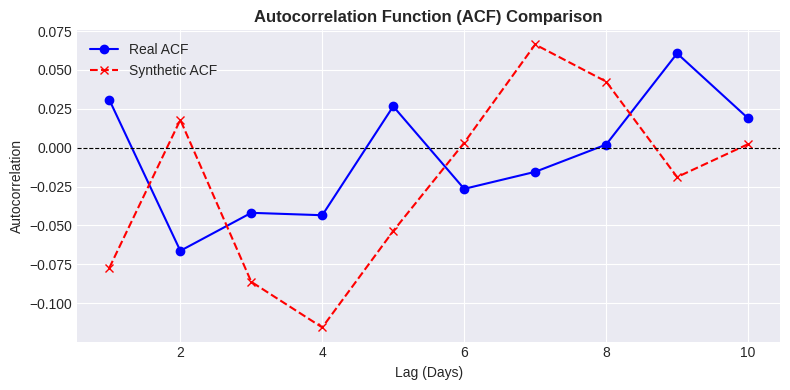

In [32]:
import numpy as np
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt

def compute_swd(X_real, X_synth, num_projections=100):

    dim = X_real.shape[1]
    swd_sum = 0.0
    
    np.random.seed(42)
    for _ in range(num_projections):
        proj = np.random.randn(dim)
        proj /= np.linalg.norm(proj)
        
        real_proj = np.dot(X_real, proj)
        synth_proj = np.dot(X_synth, proj)
        
        swd_sum += wasserstein_distance(real_proj, synth_proj)
        
    return swd_sum / num_projections

swd_value = compute_swd(X_test, synthetic_real_returns)


def compute_acf(data, max_lag=10):

    num_samples, seq_len = data.shape
    acf_values = np.zeros((num_samples, max_lag))
    
    for i in range(num_samples):
        seq = data[i]
        mean = np.mean(seq)
        var = np.var(seq)
        
        if var == 0:
            continue
            
        for lag in range(1, max_lag + 1):
            covariance = np.sum((seq[:-lag] - mean) * (seq[lag:] - mean)) / seq_len
            acf_values[i, lag-1] = covariance / var
            
    return np.mean(acf_values, axis=0)

MAX_LAG = 10
real_acf = compute_acf(X_test, max_lag=MAX_LAG)
synth_acf = compute_acf(synthetic_real_returns, max_lag=MAX_LAG)

autocorr_mse = np.mean((real_acf - synth_acf)**2)
autocorr_mean_real = np.mean(real_acf)
autocorr_mean_synth = np.mean(synth_acf)

print("=" * 50)
print("FINAL QUANTITATIVE EVALUATION")
print("=" * 50)
print(f"Sliced Wasserstein Distance (SWD): {swd_value:.6f}")
print("-" * 50)
print(f"Autocorrelation Mean (Real):       {autocorr_mean_real:.6f}")
print(f"Autocorrelation Mean (Synthetic):  {autocorr_mean_synth:.6f}")
print(f"Autocorrelation MSE:               {autocorr_mse:.8f}")
print("=" * 50)

plt.figure(figsize=(8, 4))
plt.style.use('seaborn-v0_8-darkgrid')
plt.plot(range(1, MAX_LAG + 1), real_acf, marker='o', label='Real ACF', color='blue')
plt.plot(range(1, MAX_LAG + 1), synth_acf, marker='x', label='Synthetic ACF', color='red', linestyle='--')
plt.title('Autocorrelation Function (ACF) Comparison', fontweight='bold')
plt.xlabel('Lag (Days)')
plt.ylabel('Autocorrelation')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()